Grafo utilizado:
A -> ['B', 'C']
B -> ['A', 'D', 'E']
C -> ['A', 'F']
D -> ['B']
E -> ['B', 'F']
F -> ['C', 'E']

Ingrese el nodo inicial (A-F): F


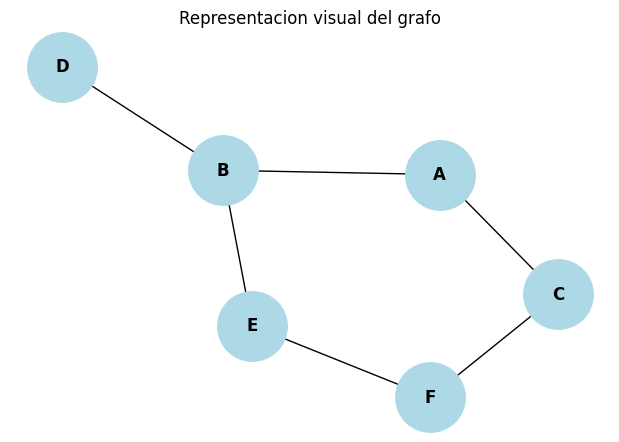


------------------------------------

Recorrido usando BFS:
Inicio: F

nodo seleccionado de la cola: F
visitados:  ['F']
agregando en cola:  C
agregando en cola:  E
cola actual:  ['C', 'E']

nodo seleccionado de la cola: C
visitados:  ['F', 'C']
agregando en cola:  A
cola actual:  ['E', 'A']

nodo seleccionado de la cola: E
visitados:  ['F', 'C', 'E']
agregando en cola:  B
cola actual:  ['A', 'B']

nodo seleccionado de la cola: A
visitados:  ['F', 'C', 'E', 'A']
cola actual:  ['B']

nodo seleccionado de la cola: B
visitados:  ['F', 'C', 'E', 'A', 'B']
agregando en cola:  D
cola actual:  ['D']

nodo seleccionado de la cola: D
visitados:  ['F', 'C', 'E', 'A', 'B', 'D']
cola actual:  []

Recorrido usando BFS: ['F', 'C', 'E', 'A', 'B', 'D']
Memoria usada por BFS: 20265 bytes

------------------------------------

Recorrido usando DFS:
Inicio: F

nodo seleccionado de la pila: F
visitados:  ['F']
agregando en pila:  C
agregando en pila:  E
pila actual:  ['C', 'E']

nodo seleccionado de la p

In [12]:
import networkx as nx
import matplotlib.pyplot as plt
import tracemalloc


grafo = {
    "A": ["B", "C"],
    "B": ["A", "D", "E"],
    "C": ["A", "F"],
    "D": ["B"],
    "E": ["B", "F"],
    "F": ["C", "E"]
}


def BFS(grafo, inicio):

    visitados = []
    cola = [inicio]

    print("Recorrido usando BFS:")
    print("Inicio:", inicio)
    print()

    while cola:

        nodo = cola.pop(0)
        print("nodo seleccionado de la cola:", nodo)

        if nodo not in visitados:

            visitados.append(nodo)
            print("visitados: ", visitados)

            for vecino in grafo[nodo]:
                if vecino not in visitados and vecino not in cola:
                    cola.append(vecino)
                    print("agregando en cola: ", vecino)

        print("cola actual: ", cola)
        print()

    return visitados


def DFS(grafo, inicio):

    visitados = []
    pila = [inicio]

    print("Recorrido usando DFS:")
    print("Inicio:", inicio)
    print()

    while pila:

        nodo = pila.pop()
        print("nodo seleccionado de la pila:", nodo)

        if nodo not in visitados:

            visitados.append(nodo)
            print("visitados: ", visitados)

            for vecino in grafo[nodo]:
                if vecino not in visitados and vecino not in pila:
                    pila.append(vecino)
                    print("agregando en pila: ", vecino)

        print("pila actual: ", pila)
        print()

    return visitados



print("Grafo utilizado:")

for nodo in grafo:
    print(nodo, "->", grafo[nodo])

print()



inicio = input("Ingrese el nodo inicial (A-F): ").strip().upper()

while inicio not in grafo:
    print("Nodo no valido")
    inicio = input("Ingrese un nodo valido (A-F): ").strip().upper()


G = nx.Graph()

for nodo in grafo:
    for vecino in grafo[nodo]:
        G.add_edge(nodo, vecino)

plt.figure(figsize=(6,4))

nx.draw(
    G,
    with_labels=True,
    node_size=2500,
    node_color="lightblue",
    font_size=12,
    font_weight="bold"
)

plt.title("Representacion visual del grafo")
plt.show()



print()
print("------------------------------------")
print()



tracemalloc.start()

resultadoBFS = BFS(grafo, inicio)

memoriaBFS = tracemalloc.get_traced_memory()[1]
tracemalloc.stop()

print("Recorrido usando BFS:", resultadoBFS)
print("Memoria usada por BFS:", memoriaBFS, "bytes")


print()
print("------------------------------------")
print()



tracemalloc.start()

resultadoDFS = DFS(grafo, inicio)

memoriaDFS = tracemalloc.get_traced_memory()[1]
tracemalloc.stop()

print("Recorrido usando DFS:", resultadoDFS)
print("Memoria usada por DFS:", memoriaDFS, "bytes")


print()
print("Nodos visitados con BFS:", len(resultadoBFS))
print("Nodos visitados con DFS:", len(resultadoDFS))